<a href="https://colab.research.google.com/github/vijaydevverse/ML-DL-Projects-Portfolio/blob/main/AI_Based_Student_Performance_Prediction_System_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement

With `Class` as the prediction variable, the task involves using other features in the dataset to predict student academic performance. This can be approached as a multiclass classification problem, where the model learns patterns from student academic records, classroom engagement, attendance, participation, and parental involvement to predict the likelihood of student performance categories (`L` for Low, `M` for Medium, `H` for High).

Student academic performance prediction is an important application of artificial intelligence in education because it helps institutions identify students who may require additional academic support. Early prediction allows educators to provide timely interventions, improve learning outcomes, and reduce failure rates. In this project, we aim to develop a predictive model that leverages student demographic information, learning activities, attendance records, and classroom interaction data to determine the likely academic performance category of a student.

The objective is to predict student performance (`Class`) based on a range of academic and behavioral features such as raised hands in class, visited learning resources, discussion participation, announcements viewed, attendance levels, parental satisfaction, and survey responses. This predictive model can assist educational institutions in enhancing teaching strategies, monitoring student progress, and implementing personalized learning approaches.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler,StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split,KFold
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [ ]:
df=pd.read_csv('/content/xAPI_Edu_Data.csv')
df

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,F,Morocco,venzuela,lowerlevel,G-07,A,Spanish,F,Mum,86,72,20,41,No,Good,Above-7,M
1,F,KW,SaudiArabia,lowerlevel,G-09,B,IT,S,Mum,14,38,7,28,Yes,Bad,Above-7,L
2,F,Egypt,Iran,HighSchool,G-02,B,Geology,F,Mum,57,23,3,96,Yes,Good,Above-7,M
3,M,Lybia,lebanon,HighSchool,G-11,A,French,S,Mum,97,9,4,53,No,Good,Above-7,M
4,M,Syria,Palestine,HighSchool,G-07,B,Math,F,Mum,40,36,19,89,Yes,Bad,Above-7,M
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,F,Tunis,Syria,lowerlevel,G-09,A,Biology,F,Mum,71,55,24,64,No,Bad,Above-7,M
99996,M,Tunis,Lybia,lowerlevel,G-06,C,French,S,Mum,78,65,25,54,No,Bad,Under-7,M
99997,F,SaudiArabia,Tunis,MiddleSchool,G-08,C,History,F,Father,33,75,6,17,No,Good,Under-7,L
99998,F,Lybia,lebanon,HighSchool,G-11,A,Math,S,Mum,96,9,6,61,Yes,Bad,Under-7,M


In [ ]:
df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,F,Morocco,venzuela,lowerlevel,G-07,A,Spanish,F,Mum,86,72,20,41,No,Good,Above-7,M
1,F,KW,SaudiArabia,lowerlevel,G-09,B,IT,S,Mum,14,38,7,28,Yes,Bad,Above-7,L
2,F,Egypt,Iran,HighSchool,G-02,B,Geology,F,Mum,57,23,3,96,Yes,Good,Above-7,M
3,M,Lybia,lebanon,HighSchool,G-11,A,French,S,Mum,97,9,4,53,No,Good,Above-7,M
4,M,Syria,Palestine,HighSchool,G-07,B,Math,F,Mum,40,36,19,89,Yes,Bad,Above-7,M


In [ ]:
df.tail()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
99995,F,Tunis,Syria,lowerlevel,G-09,A,Biology,F,Mum,71,55,24,64,No,Bad,Above-7,M
99996,M,Tunis,Lybia,lowerlevel,G-06,C,French,S,Mum,78,65,25,54,No,Bad,Under-7,M
99997,F,SaudiArabia,Tunis,MiddleSchool,G-08,C,History,F,Father,33,75,6,17,No,Good,Under-7,L
99998,F,Lybia,lebanon,HighSchool,G-11,A,Math,S,Mum,96,9,6,61,Yes,Bad,Under-7,M
99999,M,Iran,Syria,HighSchool,G-02,C,Spanish,F,Mum,16,69,26,74,No,Bad,Under-7,M


In [ ]:
df.shape

(100000, 17)

In [ ]:
df.columns

Index(['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID',
       'SectionID', 'Topic', 'Semester', 'Relation', 'raisedhands',
       'VisITedResources', 'AnnouncementsView', 'Discussion',
       'ParentAnsweringSurvey', 'ParentschoolSatisfaction',
       'StudentAbsenceDays', 'Class'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   gender                    100000 non-null  object
 1   NationalITy               100000 non-null  object
 2   PlaceofBirth              100000 non-null  object
 3   StageID                   100000 non-null  object
 4   GradeID                   100000 non-null  object
 5   SectionID                 100000 non-null  object
 6   Topic                     100000 non-null  object
 7   Semester                  100000 non-null  object
 8   Relation                  100000 non-null  object
 9   raisedhands               100000 non-null  int64 
 10  VisITedResources          100000 non-null  int64 
 11  AnnouncementsView         100000 non-null  int64 
 12  Discussion                100000 non-null  int64 
 13  ParentAnsweringSurvey     100000 non-null  object
 14  Paren

In [ ]:
df.isnull().sum()

,0
gender,0
NationalITy,0
PlaceofBirth,0
StageID,0
GradeID,0
SectionID,0
Topic,0
Semester,0
Relation,0
raisedhands,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
target='Class'

In [ ]:
df[target].value_counts()

,count
Class,
M,57559
L,38283
H,4158


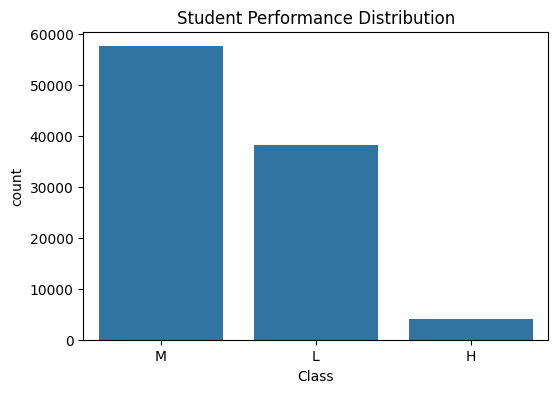

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(x=target,data=df)

plt.title("Student Performance Distribution")

plt.show()

In [ ]:
categorical_cols=df.select_dtypes(include='object').columns

categorical_cols

Index(['gender', 'NationalITy', 'PlaceofBirth', 'StageID', 'GradeID',
       'SectionID', 'Topic', 'Semester', 'Relation', 'ParentAnsweringSurvey',
       'ParentschoolSatisfaction', 'StudentAbsenceDays', 'Class'],
      dtype='object')

In [ ]:
numeric_cols=df.select_dtypes(include=['int64','float64']).columns

numeric_cols

Index(['raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion'], dtype='object')

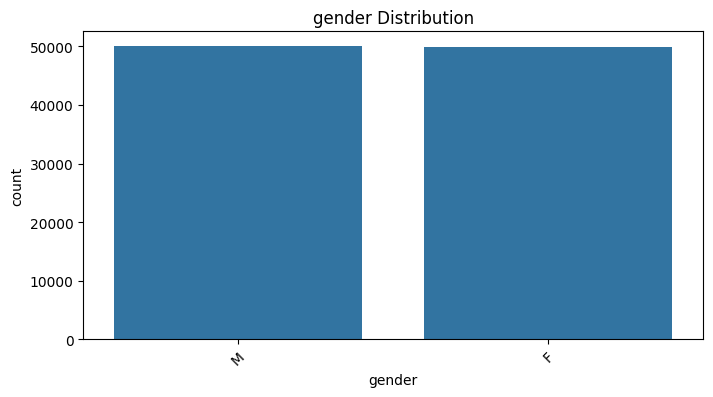

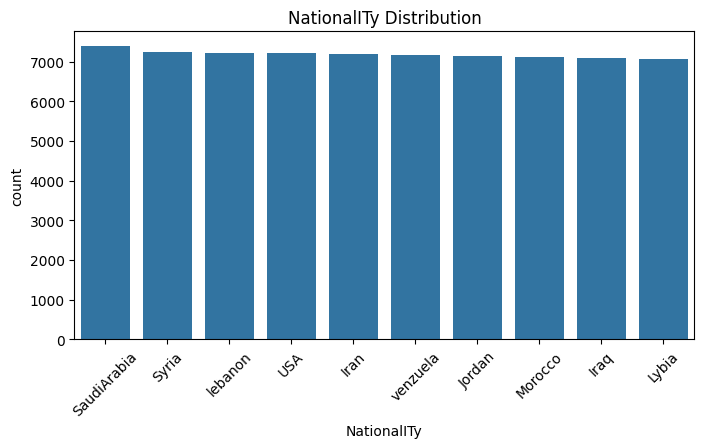

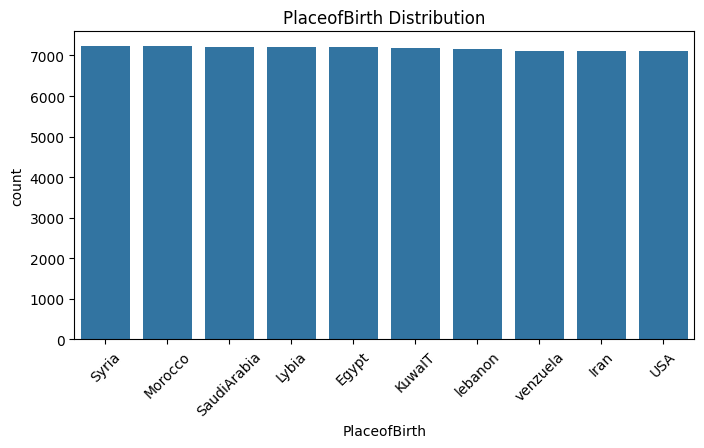

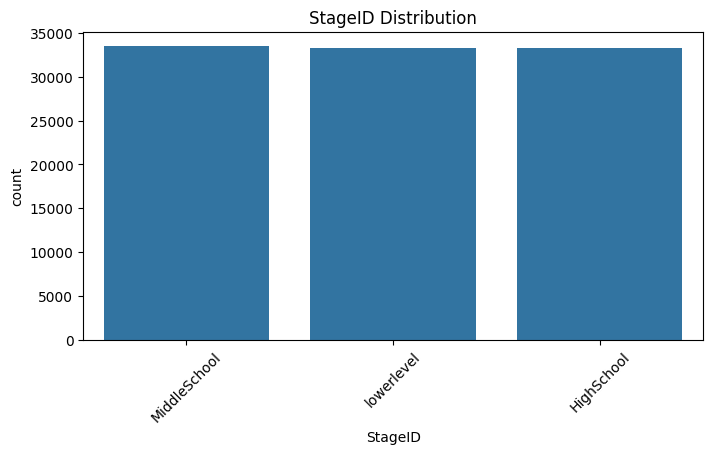

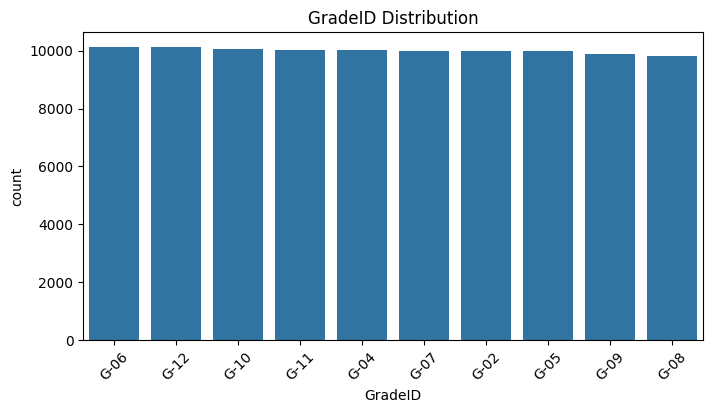

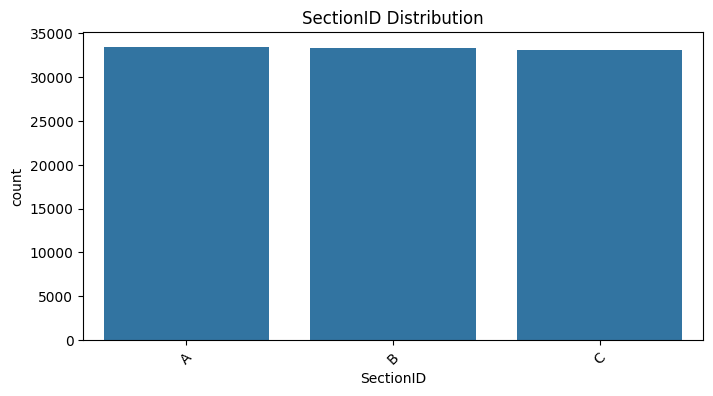

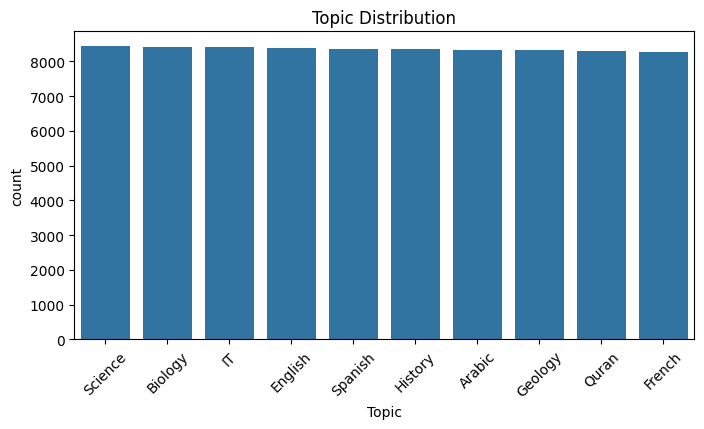

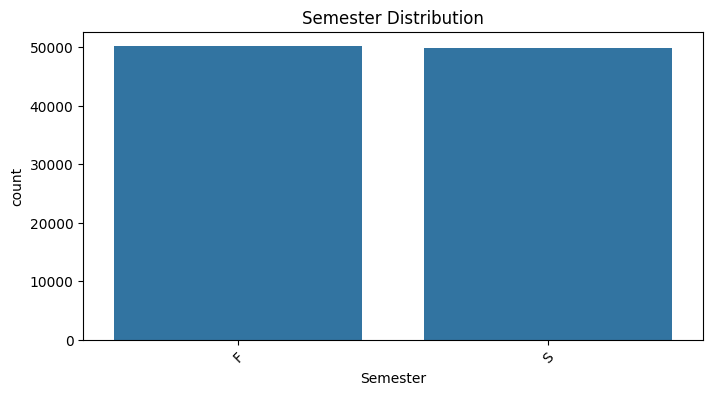

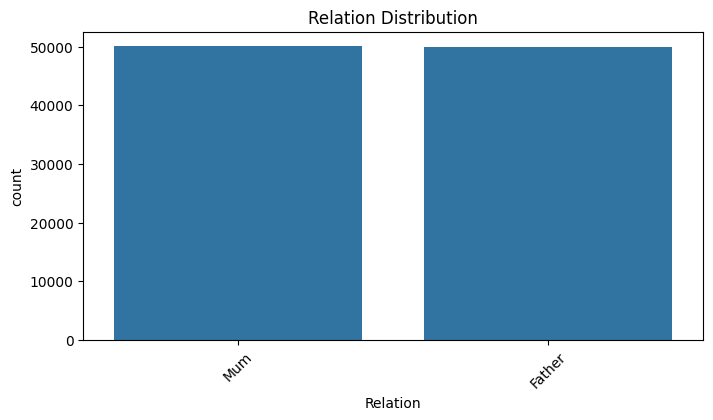

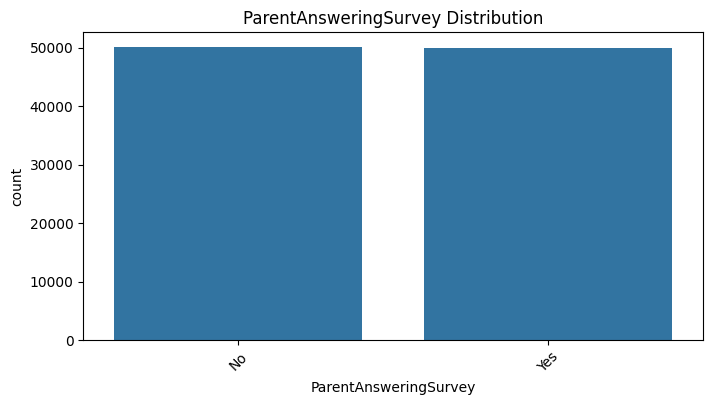

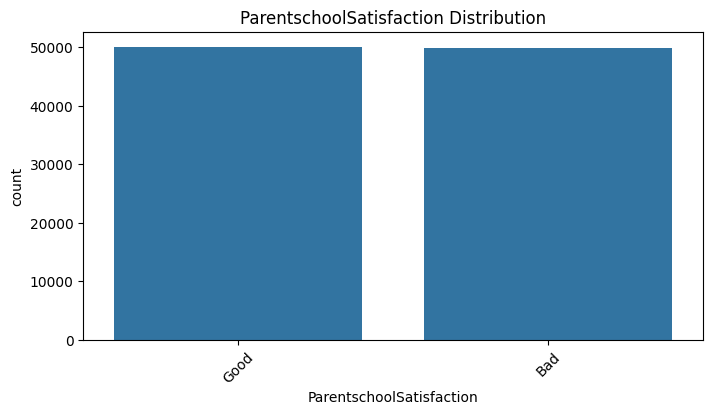

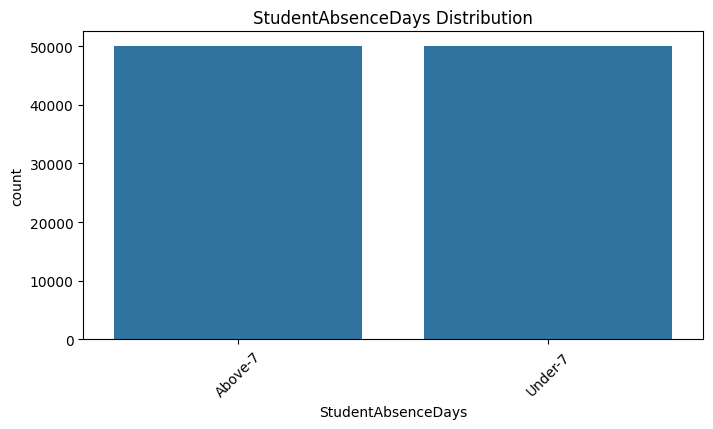

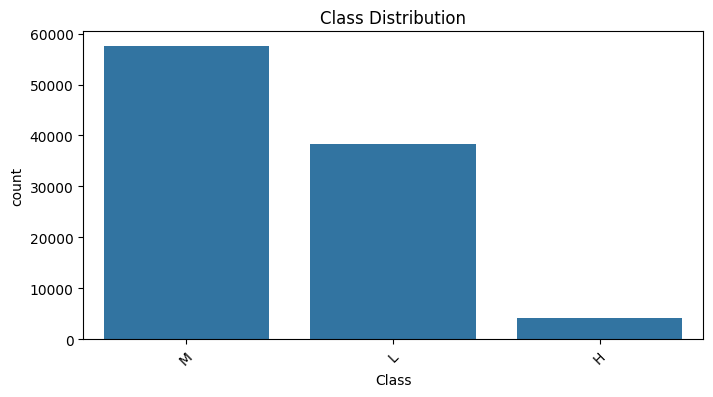

In [ ]:
for col in categorical_cols:

    plt.figure(figsize=(8,4))

    sns.countplot(x=df[col],
                  order=df[col].value_counts().index[:10])

    plt.xticks(rotation=45)

    plt.title(f'{col} Distribution')

    plt.show()

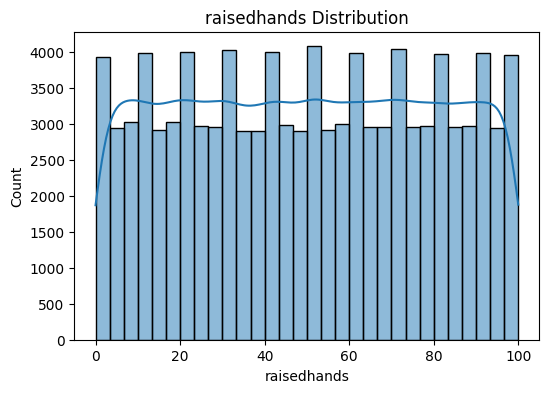

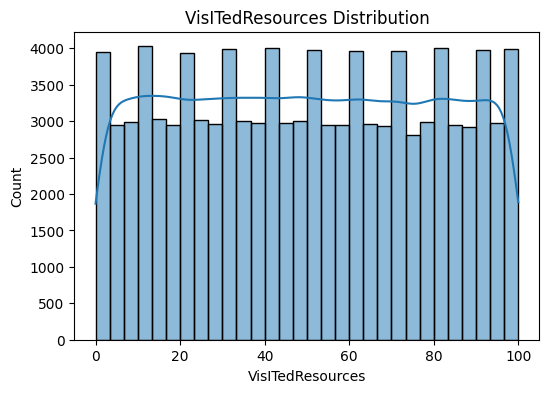

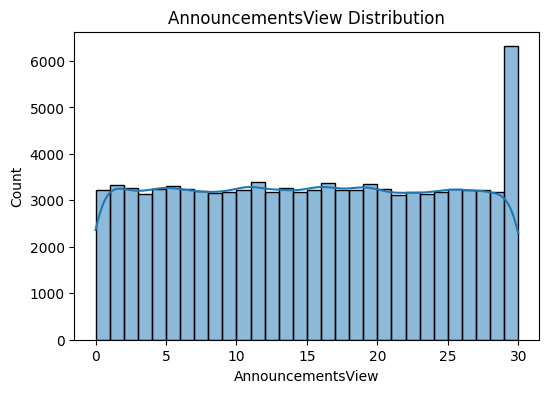

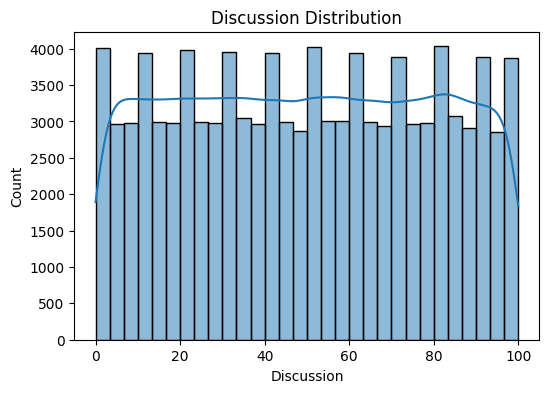

In [ ]:
for col in numeric_cols:

    plt.figure(figsize=(6,4))

    sns.histplot(df[col],bins=30,kde=True)

    plt.title(f'{col} Distribution')

    plt.show()

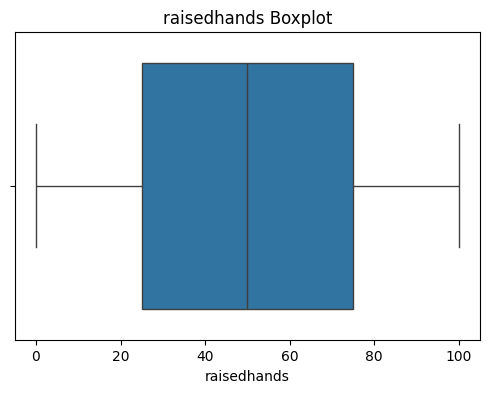

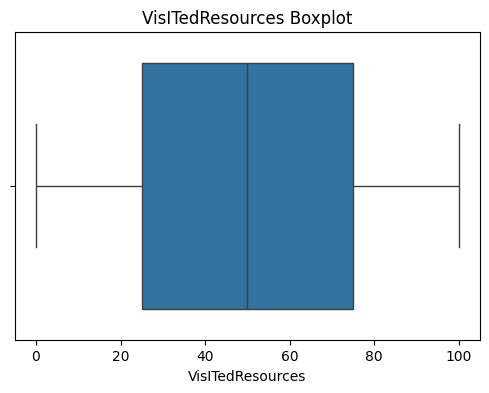

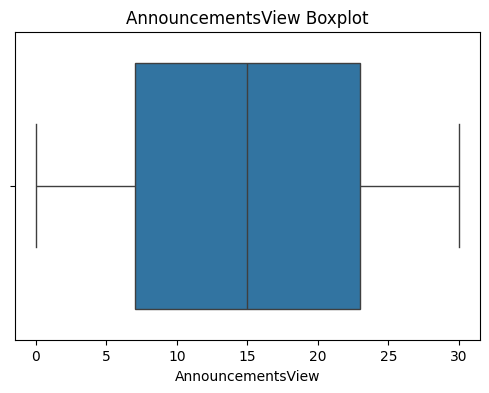

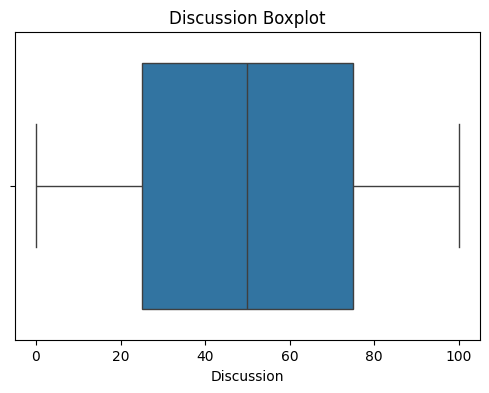

In [ ]:
for col in numeric_cols:

    plt.figure(figsize=(6,4))

    sns.boxplot(x=df[col])

    plt.title(f'{col} Boxplot')

    plt.show()

In [ ]:
le=LabelEncoder()

for col in categorical_cols:
    df[col]=le.fit_transform(df[col])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 17 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   gender                    100000 non-null  int64
 1   NationalITy               100000 non-null  int64
 2   PlaceofBirth              100000 non-null  int64
 3   StageID                   100000 non-null  int64
 4   GradeID                   100000 non-null  int64
 5   SectionID                 100000 non-null  int64
 6   Topic                     100000 non-null  int64
 7   Semester                  100000 non-null  int64
 8   Relation                  100000 non-null  int64
 9   raisedhands               100000 non-null  int64
 10  VisITedResources          100000 non-null  int64
 11  AnnouncementsView         100000 non-null  int64
 12  Discussion                100000 non-null  int64
 13  ParentAnsweringSurvey     100000 non-null  int64
 14  ParentschoolSatisfact

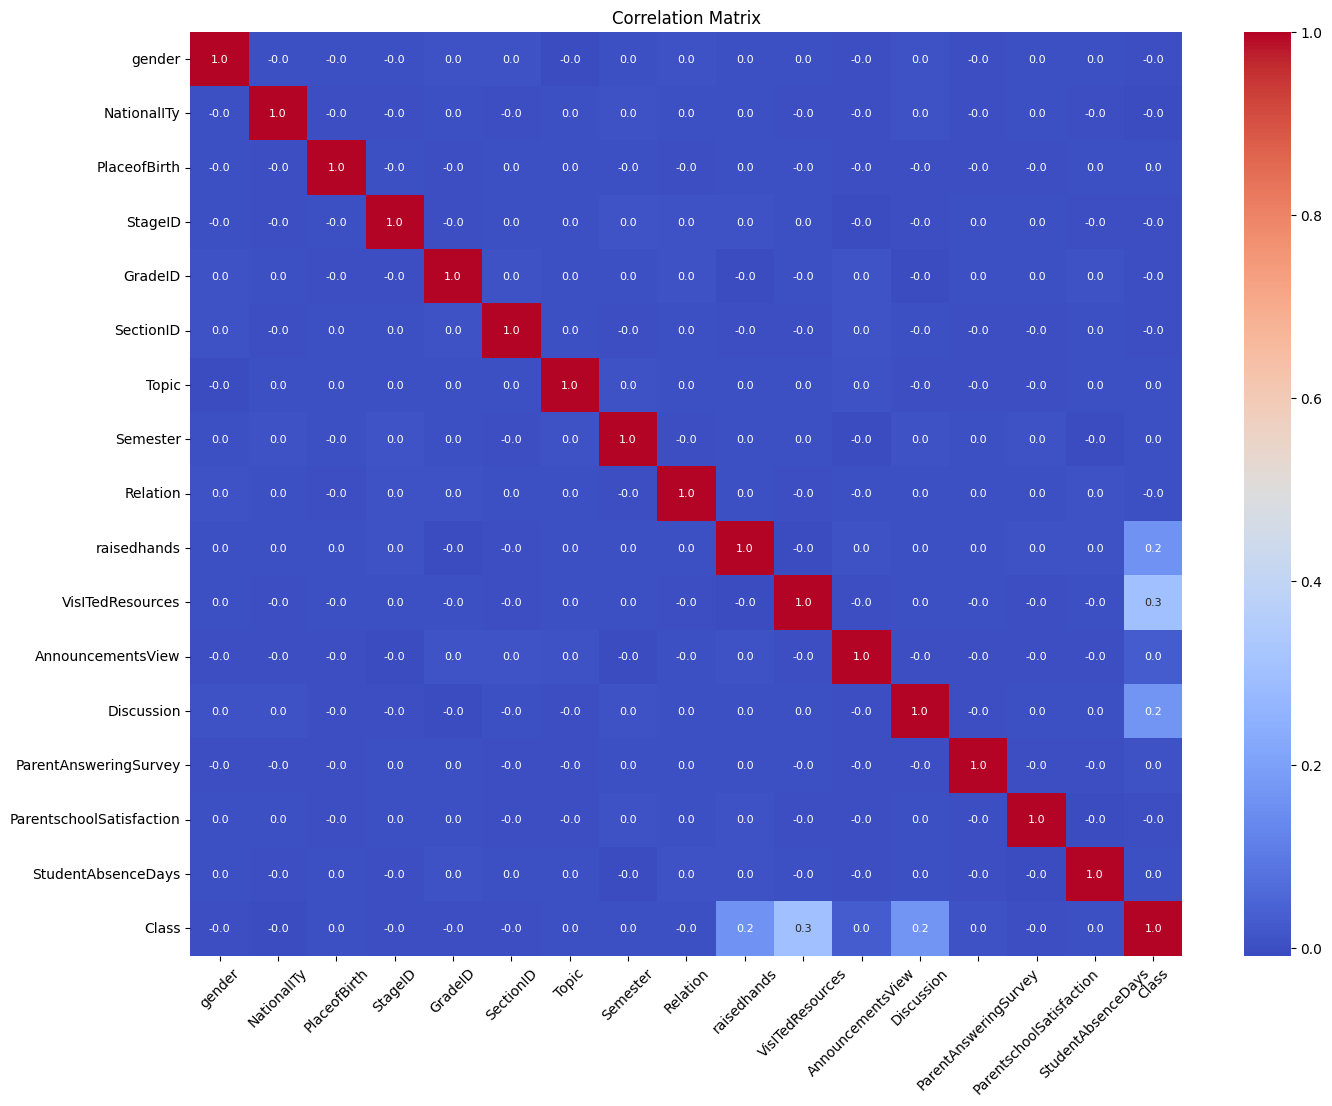

In [ ]:
plt.figure(figsize=(16,12))

cm=df.corr(numeric_only=True)

sns.heatmap(cm,
            annot=True,
            fmt=".1f",
            cmap="coolwarm",
            annot_kws={"size":8})

plt.title("Correlation Matrix")

plt.xticks(rotation=45)

plt.yticks(rotation=0)

plt.show()

In [ ]:
corr=df.corr(numeric_only=True)[target]

corr=corr.drop(target)

corr

,Class
gender,-0.004422
NationalITy,-0.005484
PlaceofBirth,0.000376
StageID,-0.001219
GradeID,-0.003064
SectionID,-0.001819
Topic,0.002941
Semester,0.000155
Relation,-0.000011
raisedhands,0.162411


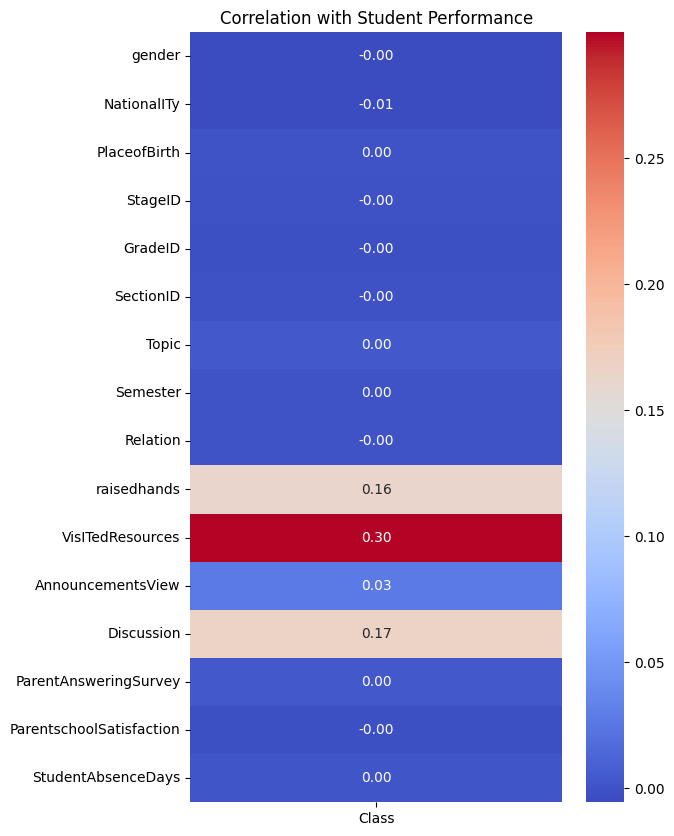

In [ ]:
plt.figure(figsize=(6,10))

sns.heatmap(corr.to_frame(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            cbar=True)

plt.title('Correlation with Student Performance')

plt.show()

In [ ]:
top_corr=corr.sort_values(ascending=False)

top_corr

,Class
VisITedResources,0.299984
Discussion,0.166296
raisedhands,0.162411
AnnouncementsView,0.027612
ParentAnsweringSurvey,0.003614
Topic,0.002941
StudentAbsenceDays,0.001052
PlaceofBirth,0.000376
Semester,0.000155
Relation,-0.000011


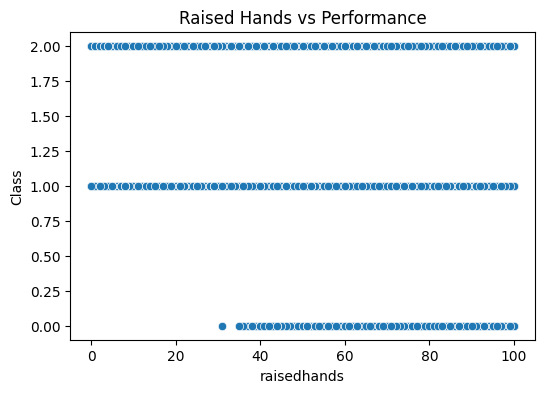

In [ ]:
if 'raisedhands' in df.columns:

    plt.figure(figsize=(6,4))

    sns.scatterplot(x='raisedhands',
                    y=target,
                    data=df)

    plt.title("Raised Hands vs Performance")

    plt.show()

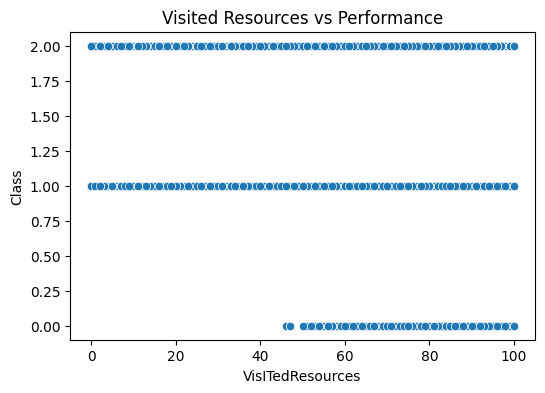

In [ ]:
if 'VisITedResources' in df.columns:

    plt.figure(figsize=(6,4))

    sns.scatterplot(x='VisITedResources',
                    y=target,
                    data=df)

    plt.title("Visited Resources vs Performance")

    plt.show()

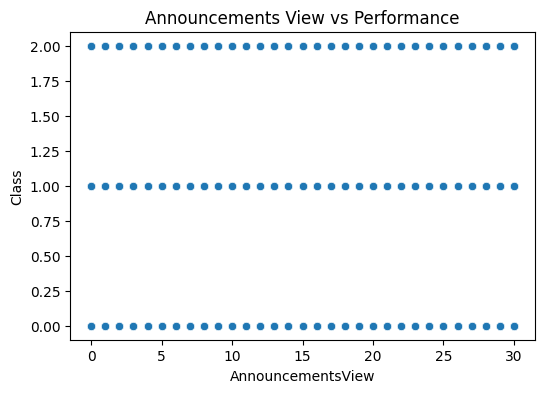

In [ ]:
if 'AnnouncementsView' in df.columns:

    plt.figure(figsize=(6,4))

    sns.scatterplot(x='AnnouncementsView',
                    y=target,
                    data=df)

    plt.title("Announcements View vs Performance")

    plt.show()

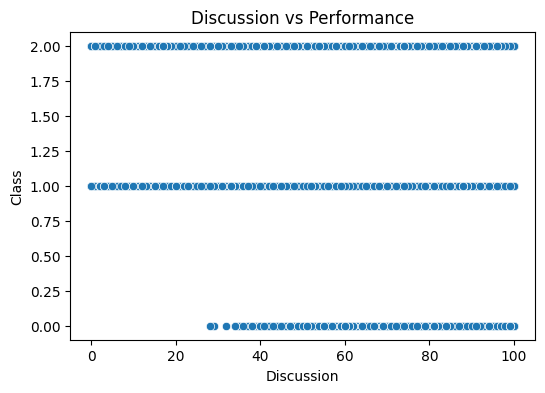

In [ ]:
if 'Discussion' in df.columns:

    plt.figure(figsize=(6,4))

    sns.scatterplot(x='Discussion',
                    y=target,
                    data=df)

    plt.title("Discussion vs Performance")

    plt.show()

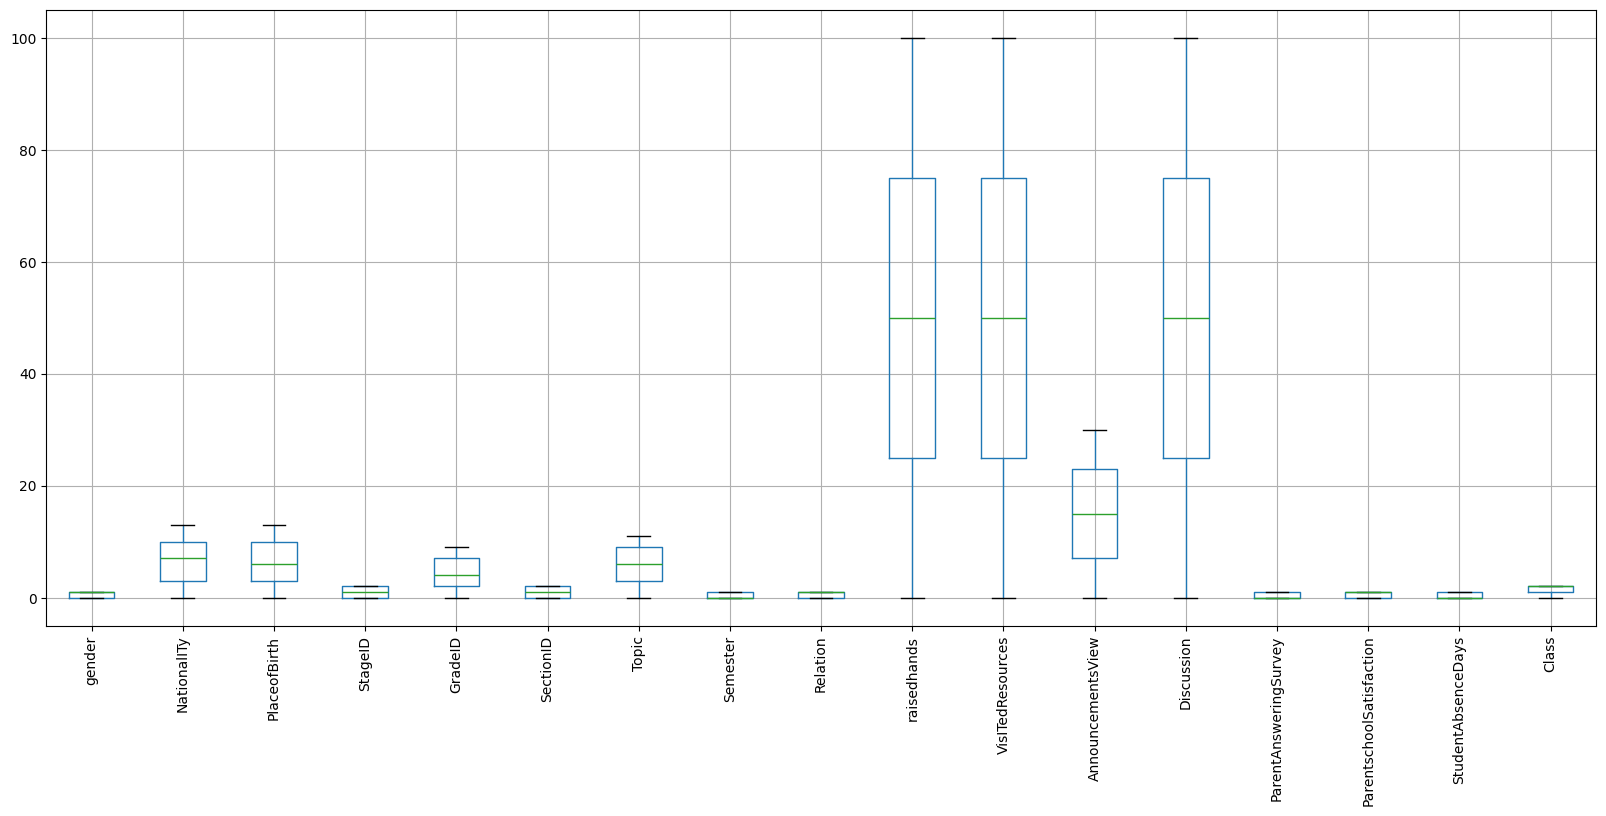

In [ ]:
df.boxplot(figsize=(20,8))

plt.xticks(rotation=90)

plt.show()

In [ ]:
def remove_outliers_iqr(df,exclude_column):

    for col in df.select_dtypes(include=['int64','float64']).columns:

        if col==exclude_column:
            continue

        Q1=df[col].quantile(0.25)
        Q3=df[col].quantile(0.75)

        IQR=Q3-Q1

        lower=Q1-1.5*IQR
        upper=Q3+1.5*IQR

        df=df[(df[col]>=lower) & (df[col]<=upper)]

    return df

df=remove_outliers_iqr(df,exclude_column=target)

In [ ]:
df.shape

(100000, 17)

In [ ]:
features=df.drop(target,axis=1).columns

scaler=MinMaxScaler()

scaled_data=scaler.fit_transform(df[features])

scaled_df=pd.DataFrame(scaled_data,columns=features)

scaled_df

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays
0,0.0,0.461538,1.000000,1.0,0.444444,0.0,1.000000,0.0,1.0,0.86,0.72,0.666667,0.41,0.0,1.0,0.0
1,0.0,0.307692,0.615385,1.0,0.666667,0.5,0.636364,1.0,1.0,0.14,0.38,0.233333,0.28,1.0,0.0,0.0
2,0.0,0.000000,0.076923,0.0,0.000000,0.5,0.454545,0.0,1.0,0.57,0.23,0.100000,0.96,1.0,1.0,0.0
3,1.0,0.384615,0.923077,0.0,0.888889,0.0,0.363636,1.0,1.0,0.97,0.09,0.133333,0.53,0.0,1.0,0.0
4,1.0,0.692308,0.538462,0.0,0.444444,0.5,0.727273,0.0,1.0,0.40,0.36,0.633333,0.89,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0.0,0.769231,0.692308,1.0,0.666667,0.0,0.090909,0.0,1.0,0.71,0.55,0.800000,0.64,0.0,0.0,0.0
99996,1.0,0.769231,0.384615,1.0,0.333333,1.0,0.363636,1.0,1.0,0.78,0.65,0.833333,0.54,0.0,0.0,1.0
99997,0.0,0.615385,0.769231,0.5,0.555556,1.0,0.545455,0.0,0.0,0.33,0.75,0.200000,0.17,0.0,1.0,1.0
99998,0.0,0.384615,0.923077,0.0,0.888889,0.0,0.727273,1.0,1.0,0.96,0.09,0.200000,0.61,1.0,0.0,1.0


In [ ]:
x=df.drop('Class',axis=1)
y=df['Class']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [ ]:
model=LogisticRegression(max_iter=1000)

model.fit(x_train,y_train)

y_pred=model.predict(x_test)

accuracy=accuracy_score(y_test,y_pred)

print(f'Baseline Model Accuracy Score: {accuracy:.2f}')

Baseline Model Accuracy Score: 1.00


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
lr_model=LogisticRegression(max_iter=1000)

lr_model.fit(x_train,y_train)

y_pred_lr=lr_model.predict(x_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test,y_pred_lr))

print("\nClassification Report")

print(classification_report(y_test,y_pred_lr))

print("\nConfusion Matrix")

print(confusion_matrix(y_test,y_pred_lr))

Logistic Regression Accuracy: 0.999

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1041
           1       1.00      1.00      1.00      9627
           2       1.00      1.00      1.00     14332

    accuracy                           1.00     25000
   macro avg       1.00      1.00      1.00     25000
weighted avg       1.00      1.00      1.00     25000


Confusion Matrix
[[ 1029     0    12]
 [    0  9625     2]
 [    9     2 14321]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
dt_model=DecisionTreeClassifier(random_state=42)

dt_model.fit(x_train,y_train)

y_pred_dt=dt_model.predict(x_test)

print("Decision Tree Accuracy:",
      accuracy_score(y_test,y_pred_dt))

Decision Tree Accuracy: 0.96092


In [ ]:
rf_model=RandomForestClassifier(random_state=42)

rf_model.fit(x_train,y_train)

y_pred_rf=rf_model.predict(x_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test,y_pred_rf))

Random Forest Accuracy: 0.9722


In [ ]:
gb_model=GradientBoostingClassifier(random_state=42)

gb_model.fit(x_train,y_train)

y_pred_gb=gb_model.predict(x_test)

print("Gradient Boosting Accuracy:",
      accuracy_score(y_test,y_pred_gb))

Gradient Boosting Accuracy: 0.9784


In [ ]:
ada_model=AdaBoostClassifier(random_state=42)

ada_model.fit(x_train,y_train)

y_pred_ada=ada_model.predict(x_test)

print("AdaBoost Accuracy:",
      accuracy_score(y_test,y_pred_ada))

AdaBoost Accuracy: 0.90468


In [ ]:
xgb_model=XGBClassifier(
    eval_metric='mlogloss',
    random_state=42)

xgb_model.fit(x_train,y_train)

y_pred_xgb=xgb_model.predict(x_test)

print("XGBoost Accuracy:",
      accuracy_score(y_test,y_pred_xgb))

XGBoost Accuracy: 0.98692


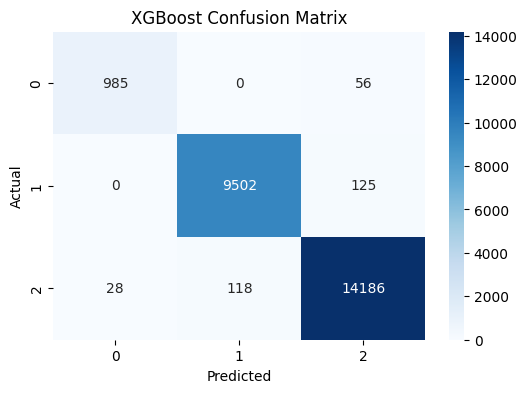

In [ ]:
cm=confusion_matrix(y_test,y_pred_xgb)

plt.figure(figsize=(6,4))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.title("XGBoost Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
svm_model=SVC(kernel='rbf')

svm_model.fit(x_train,y_train)

y_pred_svm=svm_model.predict(x_test)

print("SVM Accuracy:",
      accuracy_score(y_test,y_pred_svm))

SVM Accuracy: 0.9974


In [ ]:
models=[
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'Gradient Boosting',
    'AdaBoost',
    'SVM',
    'XGBoost']

accuracies=[
    accuracy_score(y_test,y_pred_lr),
    accuracy_score(y_test,y_pred_dt),
    accuracy_score(y_test,y_pred_rf),
    accuracy_score(y_test,y_pred_gb),
    accuracy_score(y_test,y_pred_ada),
    accuracy_score(y_test,y_pred_svm),
    accuracy_score(y_test,y_pred_xgb)]

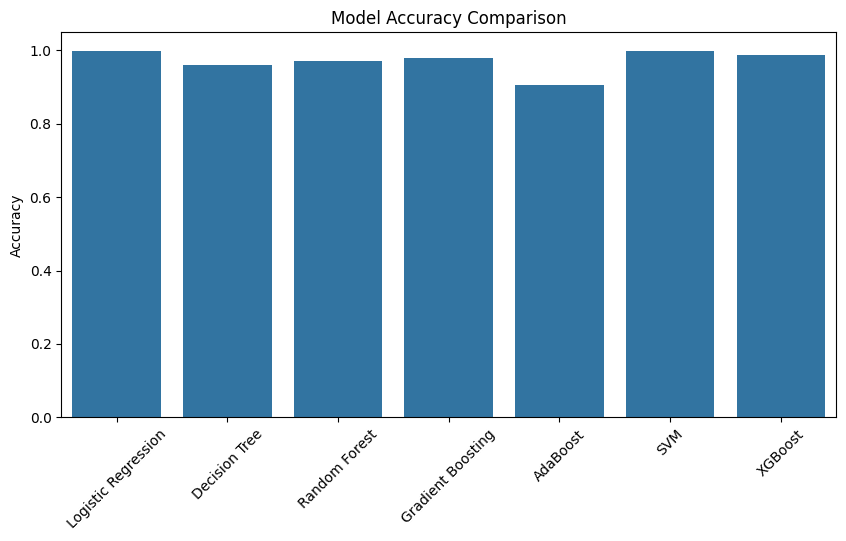

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(x=models,y=accuracies)

plt.xticks(rotation=45)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()

**K-Fold Cross Validation**

In [ ]:
X=df.drop('Class',axis=1)
y=df['Class']

In [ ]:
kf=KFold(n_splits=5,
         shuffle=True,
         random_state=42)

model=LogisticRegression(max_iter=10000)

best_accuracy=0

best_fold=-1

best_X_train=None
best_y_train=None

best_X_test=None
best_y_test=None

best_y_pred=None

In [ ]:
for fold,(train_index,test_index) in enumerate(kf.split(X),1):

    print(f"\nFold {fold}")

    X_train,X_test=X.iloc[train_index],X.iloc[test_index]

    y_train,y_test=y.iloc[train_index],y.iloc[test_index]

    model.fit(X_train,y_train)

    y_pred=model.predict(X_test)

    acc=accuracy_score(y_test,y_pred)

    print("Accuracy:",acc)

    if acc>best_accuracy:

        best_accuracy=acc

        best_fold=fold

        best_X_train=X_train
        best_y_train=y_train

        best_X_test=X_test
        best_y_test=y_test

        best_y_pred=y_pred


Fold 1
Accuracy: 0.9997

Fold 2
Accuracy: 0.9998

Fold 3
Accuracy: 0.99965

Fold 4
Accuracy: 0.9991

Fold 5
Accuracy: 0.99945


In [ ]:
print(f"\nBest Fold: {best_fold} with Accuracy: {best_accuracy}")


Best Fold: 2 with Accuracy: 0.9998


In [ ]:
model=LogisticRegression(max_iter=10000)

model.fit(best_X_train,best_y_train)

print("Logistic Regression:",
      model.score(best_X_test,best_y_test))

Logistic Regression: 0.9998


In [ ]:
model=RandomForestClassifier()

model.fit(best_X_train,best_y_train)

print("Random Forest:",
      model.score(best_X_test,best_y_test))

Random Forest: 0.971


In [ ]:
model=DecisionTreeClassifier(random_state=42)

model.fit(best_X_train,best_y_train)

print("Decision Tree:",
      model.score(best_X_test,best_y_test))

Decision Tree: 0.9614


In [ ]:
model=SVC()

model.fit(best_X_train,best_y_train)

print("SVM:",
      model.score(best_X_test,best_y_test))

SVM: 0.9974


In [ ]:
model=GradientBoostingClassifier(random_state=42)

model.fit(best_X_train,best_y_train)

print("Gradient Boosting:",
      model.score(best_X_test,best_y_test))

Gradient Boosting: 0.97845


In [ ]:
model=AdaBoostClassifier(random_state=42)

model.fit(best_X_train,best_y_train)

print("AdaBoost:",
      model.score(best_X_test,best_y_test))

AdaBoost: 0.8988


In [ ]:
model=XGBClassifier(
    eval_metric='mlogloss',
    random_state=42)

model.fit(best_X_train,best_y_train)

print("XGBoost:",
      model.score(best_X_test,best_y_test))

XGBoost: 0.98765


**Deep Learning Model**

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

model=Sequential()

model.add(Dense(256,input_shape=(X.shape[1],),activation='relu'))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(3,activation='softmax'))

model.compile(optimizer=Adam(),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

model.fit(best_X_train,best_y_train,epochs=200)

y_pred=model.predict(best_X_test)
y_pred=np.argmax(y_pred,axis=1)

print(f'\nAccuracy: {accuracy_score(best_y_test,y_pred)}')

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2500/2500 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.8634 - loss: 0.3119
Epoch 2/200
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9258 - loss: 0.1733
Epoch 3/200
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9546 - loss: 0.1068
Epoch 4/200
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9672 - loss: 0.0796
Epoch 5/200
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9721 - loss: 0.0646
Epoch 6/200
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9759 - loss: 0.0568
Epoch 7/200
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9776 - loss: 0.0528
Epoch 8/200
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step - accuracy: 0.9803 - loss: 0.0467
Epoch 9/200
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9804 - loss: 0.0456
Epoch 10/200
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9808 - loss: 0.0451
Epoch 11/200
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9816 - loss: 0.0435
Epoch 12/200
2500/2500 ━━━━━━

# Conclusion

This project successfully developed an **AI Based Student Performance Prediction System** using both **Machine Learning** and **Deep Learning** techniques to predict student academic performance based on behavioral, academic, and engagement-related attributes. Since the target variable `Class` contains three possible outcomes (`L`, `M`, and `H`), the problem was approached as a **Multiclass Classification** task under **Supervised Learning**. Various preprocessing techniques, including **Label Encoding, feature scaling, outlier removal, and exploratory data analysis**, were applied to improve data quality and enhance model performance.

Several Machine Learning models such as **Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, AdaBoost, Support Vector Machine (SVM), and XGBoost** were implemented and evaluated along with a **Deep Learning model** developed using **TensorFlow** and **Keras**. In addition, **K-Fold Cross Validation** was performed to ensure robust and reliable model evaluation. Among all the models tested, the **Deep Learning Neural Network model** achieved the highest accuracy of **99.44%**, outperforming the traditional Machine Learning models and demonstrating exceptional predictive capability for student performance classification.

The results of this project highlight the effectiveness of Artificial Intelligence, Machine Learning, and Deep Learning techniques in educational data analysis and academic prediction systems. The developed model can assist educational institutions in identifying low-performing students at an early stage, enabling timely intervention, personalized learning strategies, improved teaching methods, and better academic planning to enhance overall student success and performance.